# Chatbot With Memory

In [ ]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [2]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

## 그래프 구성

In [8]:
from typing import TypedDict, Annotated, List       # 타입 힌트 도구
from langgraph.graph.message import add_messages    # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    # messages 필드가 add_messages 규칙으로 누적 저장
    messages: Annotated[List, add_messages] 

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 바인딩

# State의 messages 를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    # 누적된 메시지 리스트로 LLM 호출
    response = llm_with_tools.invoke(state['messages']) 
    # add_messages 규칙에 의해 기존 messages에 응답이 누적됨. 
    return {'messages': [response]}    

## 메모리 저장소

In [9]:
# 메모리 기반 체크포인트 저장소 ( 인메모리 )
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() # 상태 체크포인트를 RAM에 저장하는 객체

<class 'langgraph.graph.state.CompiledStateGraph'>


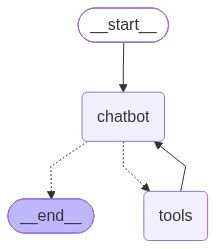

In [20]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# State 스키마 기반 그래프 설계 객체 생성
builder = StateGraph(State) 
tool_node = ToolNode(tools)

# 시작 노드 -> chatbot 노드
builder.add_edge(START, 'chatbot') 

builder.add_node('chatbot', chatbot) # chatbot 노드
builder.add_node('tools', tool_node) # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools','chatbot')

graph = builder.compile(checkpointer = memory) # 체크포인터를 포함하여 실행 가능한 그래프로 컴파일
print(type(graph)) # 그래프 타입 확인
graph # 그래프 객체

In [21]:
from pprint import pprint

user1_config = {'configurable' : {'thread_id': 'user1'}}

state = {'messages' : [('human', '안녕~ 나는 cap이라고 해! 만나서 반갑다!!')]} 

# 그래프 실행(START -> CHATBOT -> (tool 루프) or END)
response = graph.invoke(state, user1_config) 
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='안녕~ 나는 cap이라고 해! 만나서 반갑다!!', additional_kwargs={}, response_metadata={}, id='bc05e627-ab2a-45ab-be33-5cda429d4574'),
              AIMessage(content='안녕 cap! 만나서 반가워요 😊  \n편하게 cap이라고 불러도 될까요? 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 1282, 'total_tokens': 1315, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrgx9SFIzKEuWFglkNtPIxSD40yo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06525-2d32-77b0-b1cb-b5a56033d013-0', tool_calls=[], invalid_tool_calls=[], usage_metad

In [22]:
user2_config = {'configurable' : {'thread_id': 'user2'}}

state = {'messages' : [('human', '내 이름이 뭐라고 했지? 요즘 기억이 안나네~')]} 

# 그래프 실행(START -> CHATBOT -> (tool 루프) or END)
response = graph.invoke(state, user2_config) 
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='내 이름이 뭐라고 했지? 요즘 기억이 안나네~', additional_kwargs={}, response_metadata={}, id='ce7a20d6-2c41-41a5-bdb9-4f134ecf7f3e'),
              AIMessage(content='미안, 나는 이전 대화에서 네 이름을 기억해두지 못해.  \n이 대화에서 아직 이름을 알려주지 않았다면 나는 몰라.\n\n원하면 지금 알려줘. 내가 그 이름으로 불러줄게 🙂', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 1284, 'total_tokens': 1337, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrjMZiydKGgJ9PNqHwrld5LeoCGK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06527-7203-7b61-a221-bf5417f71bd7-0', tool

In [24]:
# 체크포인터에 저장된 특정 thread id의 대화 스냅샷 조회
snapshot = graph.get_state(user1_config)
print(snapshot)
print(snapshot.values['messages'])

StateSnapshot(values={'messages': [HumanMessage(content='안녕~ 나는 cap이라고 해! 만나서 반갑다!!', additional_kwargs={}, response_metadata={}, id='bc05e627-ab2a-45ab-be33-5cda429d4574'), AIMessage(content='안녕 cap! 만나서 반가워요 😊  \n편하게 cap이라고 불러도 될까요? 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 1282, 'total_tokens': 1315, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrgx9SFIzKEuWFglkNtPIxSD40yo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06525-2d32-77b0-b1cb-b5a56033d013-0', tool_calls=[], invalid_tool_calls=[], usag

In [ ]:
all_snapshot = memory.list({}) # memory에 저장된 전체 스냅샷 리스트 조회

for snapshot in all_snapshot:
    print(f"Thread ID : {snapshot.config['configurable']['thread_id']}") # thread_id
    if 'messages' in snapshot.checkpoint['channel_values']: # messages 채널 값 존재
        # 해당 스냅샷의 누적 messages 출력
        pprint(snapshot.checkpoint['channel_values']['messages']) 
    else:
        print("스냅샷에 저장한 메시지가 없습니다.")
    print()


Thread ID : user1
[HumanMessage(content='안녕~ 나는 cap이라고 해! 만나서 반갑다!!', additional_kwargs={}, response_metadata={}, id='bc05e627-ab2a-45ab-be33-5cda429d4574'),
 AIMessage(content='안녕 cap! 만나서 반가워요 😊  \n편하게 cap이라고 불러도 될까요? 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 1282, 'total_tokens': 1315, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrgx9SFIzKEuWFglkNtPIxSD40yo', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06525-2d32-77b0-b1cb-b5a56033d013-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'in

memory 상에 대화간 입력했던 내용들이 스냅샷으로 저장되고,   
이 스냅샷에서 최종 대화내용 중 실제 대화만 꺼내어 영속적인 DB에 저장하여 유지한다.